# Cell 0 — Setup & Installs

In [ ]:
# --- Safe Cell 0: minimal deps, no auto-kill ---
%pip -q install --upgrade pip setuptools wheel

# Keep NumPy at 2.0.2 (compatible with numba 0.60 preinstalled in Colab)
# Add jedi for the old IPython in some Colab images
# Keep deps minimal for this standalone notebook
%pip -q install --no-warn-conflicts \
  numpy==2.0.2 \
  pandas==2.2.2 \
  scipy==1.14.1 \
  scikit-learn==1.6.1 \
  xgboost==3.0.4 \
  statsmodels==0.14.2 \
  "jedi>=0.16"

import numpy as np, pandas as pd, xgboost as xgb
import statsmodels.api as sm
print("VERSIONS ->",
      "numpy", np.__version__,
      "pandas", pd.__version__,
      "sklearn", __import__('sklearn').__version__,
      "xgboost", xgb.__version__,
      "statsmodels", sm.__version__)
print("✅ Installs complete. Now do: Runtime → Restart runtime (once), then run Cell 1.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
VERSIONS -> numpy 2.0.2 pandas 2.2.2 sklearn 1.6.1 xgboost 3.0.4 statsmodels 0.14.2
✅ Installs complete. Now do: Runtime → Restart runtime (once), then run Cell 1.


In [ ]:
import warnings, random; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import xgboost as xgb, shap
import tensorflow as tf
from tensorflow import keras
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon, binomtest

print("VERSIONS ->",
      "numpy", np.__version__,
      "pandas", pd.__version__,
      "sklearn", __import__('sklearn').__version__,
      "xgboost", xgb.__version__,
      "shap", shap.__version__,
      "tensorflow", tf.__version__)


VERSIONS -> numpy 2.0.2 pandas 2.2.2 sklearn 1.6.1 xgboost 3.0.4 shap 0.48.0 tensorflow 2.19.0


# Cell 1 — Load your CSV from Drive

In [ ]:
# Reproducible seeds (numpy / python / TF optional)
import os, random
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

# If you’re using TensorFlow later:
# import tensorflow as tf
# tf.keras.utils.set_random_seed(SEED)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/renewables_outputs/merged_by_continent/refined dataset/refined_df.csv"
df = pd.read_csv(CSV_PATH, low_memory=False)
print(df.shape)

# Clean up column names (remove leading/trailing whitespace)
df.columns = df.columns.str.strip()
print("DataFrame columns after cleaning:", df.columns.tolist())

# timestamp detection + sort
time_candidates = [c for c in df.columns if c.lower() in ("timestamp","time","datetime","date","utc_time","ds", "time_utc", "ts_utc")]
print("Time candidates:", time_candidates)
assert time_candidates, "No time column found; rename your time column to 'timestamp' or 'datetime'."
TIME_COL = time_candidates[0]
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors='coerce')
df = df.sort_values(TIME_COL).dropna(subset=[TIME_COL]).reset_index(drop=True)

# de-duplicate columns (common cause of huge runtimes)
df = df.loc[:, ~df.columns.duplicated()].copy()

# numeric downcast for memory
for c in df.select_dtypes(include=["float64"]).columns: df[c] = pd.to_numeric(df[c], downcast="float")
for c in df.select_dtypes(include=["int64"]).columns:   df[c] = pd.to_numeric(df[c], downcast="integer")

# detect targets
possible_targets = [c for c in df.columns if c.lower() in ("target_solar_mw","target_wind_mw")]
if not possible_targets:
    for c in df.columns:
        cl = c.lower()
        if "solar" in cl and "mw" in cl: possible_targets.append(c)
        if "wind"  in cl and "mw" in cl: possible_targets.append(c)
possible_targets = list(dict.fromkeys(possible_targets))
print("Targets:", possible_targets)
assert possible_targets, "No target_*_mw column detected. Set `possible_targets` manually."

Mounted at /content/drive
(2698080, 24)
DataFrame columns after cleaning: ['site_id', 'lat', 'lon', 'met_ghi', 'met_dni', 'met_dhi', 'met_temp_c', 'met_pressure_hpa', 'met_cloud_cover', 'met_wind_speed_10m', 'met_wind_speed_100m', 'target_wind_mw', 'target_solar_mw', 'continent', 'ts_utc', 'ts_local', 'hour', 'doy', 'month', 'weekday', 'is_weekend', 'is_daylight', 'solar_struct_zero', 'wind_near_zero']
Time candidates: ['ts_utc']
Targets: ['target_wind_mw', 'target_solar_mw']


# Cell 2 — Identify categoricals, cadence, horizons

In [ ]:
# ---- Cell 2 (robust): Cadence detection from UNIQUE timestamps + horizon list ----
import pandas as pd
import numpy as np

def detect_base_minutes_from_unique(ts: pd.Series) -> int:
    """
    Detect base sampling interval in minutes for panel data.
    Uses unique, sorted timestamps so duplicates across sites don't create 0-second diffs.
    """
    s = pd.to_datetime(ts, utc=True, errors="coerce").dropna().sort_values().drop_duplicates()
    if s.size < 2:
        return 60  # safe default
    diffs = s.diff().dropna().dt.total_seconds()
    diffs = diffs[diffs > 0]  # ignore 0-second gaps
    if diffs.empty:
        return 60
    # Prefer the statistical mode; fall back to median/min positive if needed
    mode = diffs.mode()
    sec = float(mode.iloc[0]) if not mode.empty else float(diffs.median())
    # Guardrails
    if not np.isfinite(sec) or sec <= 0:
        return 60
    minutes = int(round(sec / 60.0))
    return max(1, minutes)

# Detect cadence safely
base_minutes = detect_base_minutes_from_unique(df[TIME_COL])
# Horizons compatible with cadence (include 15 only if cadence <= 15)
HORIZONS = [15, 60, 1440] if base_minutes <= 15 else [60, 1440]

print("Base cadence (min):", base_minutes)
print("Planned horizons (min):", HORIZONS)

# Sanity: implied steps per horizon
for hz in HORIZONS:
    if hz % base_minutes != 0:
        print(f"⚠️ Horizon {hz} is NOT a multiple of cadence {base_minutes} — will be skipped.")
    else:
        print(f"Horizon {hz}: steps = {hz // base_minutes}")


Base cadence (min): 60
Planned horizons (min): [60, 1440]
Horizon 60: steps = 1
Horizon 1440: steps = 24


# Cell 3 — Utilities: CV folds, metrics, supervised builder

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

def generate_folds(df_time_sorted, time_col, n_splits=4, test_size=None, gap=None):
    if test_size is None: test_size = int(len(df_time_sorted) * 0.15)
    if gap is None: gap = max(1, int(test_size*0.05))
    step = int((len(df_time_sorted) - test_size - gap) / n_splits)
    folds = []
    for k in range(n_splits):
        train_end = (k+1)*step
        valid_start = train_end + gap
        valid_end = valid_start + test_size
        if valid_end >= len(df_time_sorted): break
        train_idx = np.arange(0, train_end)
        valid_idx = np.arange(valid_start, valid_end)
        folds.append((train_idx, valid_idx))
    return folds

def infer_freq_minutes_strict(ts):
    diffs = ts.sort_values().diff().dt.total_seconds().dropna()
    if diffs.empty:
        return None
    mode = diffs.mode()
    return int(round((mode.iloc[0]) / 60.0)) if len(mode) else None

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = rmse_np(y_true, y_pred)   # robust RMSE (no 'squared=' kw)
    nmae = mae / (np.nanmax(y_true) - np.nanmin(y_true) + 1e-9)
    return dict(MAE=mae, RMSE=rmse, nMAE=nmae)

def build_supervised(df_in, time_col, target_col, horizon_minutes, base_minutes):
    steps = max(1, horizon_minutes // base_minutes)
    y_future = df_in[target_col].shift(-steps)
    X = df_in.drop(columns=[target_col]).copy()
    X["y"] = y_future
    X = X.dropna(subset=["y"]).reset_index(drop=True)
    return X.drop(columns=["y"]), X["y"].astype(np.float32), steps

def build_xgb_pipeline(numeric_cols, categorical_cols):
    # local, GPU-aware params
    def _has_gpu():
        try:
            import tensorflow as tf
            return bool(tf.config.list_physical_devices('GPU'))
        except Exception:
            return False
    tree_method = "gpu_hist" if _has_gpu() else "hist"

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, max_categories=256)
    pre = ColumnTransformer(
        transformers=[("num","passthrough",numeric_cols), ("cat",ohe,categorical_cols)],
        sparse_threshold=0.3, n_jobs=-1
    )
    model = xgb.XGBRegressor(
        booster="gbtree",
        tree_method=tree_method,
        max_depth=8, max_bins=256,
        n_estimators=4000, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.0,
        random_state=SEED, n_jobs=-1
    )
    return Pipeline([("pre", pre), ("xgb", model)])



# Cell 4 — RQ1 & RQ2 runner with fast baselines + XGB

In [ ]:
# ---- Crash-safe runner: bounded RAM/cores, compact OHE, smaller models ----
def run_rq1_rq2(df_sorted, time_col, target_col, horizons_min, n_splits=3,
                seasonal_period_min=1440, base_minutes=60, use_xgb=True,
                max_rows_per_fold=50_000,  # tighter cap
                seed=42, verbosity=True):

    import numpy as np, gc
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.compose import ColumnTransformer
    import xgboost as xgb

    rng = np.random.default_rng(seed)
    rows = []

    # GPU-aware tree_method, but keep n_jobs small to avoid forks
    def _has_gpu():
        try:
            import tensorflow as tf
            return bool(tf.config.list_physical_devices('GPU'))
        except Exception:
            return False

    def _xgb_params_local():
        return dict(
            booster="gbtree",
            tree_method="gpu_hist" if _has_gpu() else "hist",
            max_depth=6,            # shallower trees
            max_bins=256,
            n_estimators=2000,      # fewer rounds; early stopping below
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            random_state=seed,
            n_jobs=2,               # avoid many worker threads
            verbosity=0
        )

    # Drop time-like / free-text columns that explode OHE
    DROP_ALWAYS = {"ts_local", "local_time", "datetime_local", "date_local"}

    for hz in horizons_min:
        # --- guard incompatible horizons ---
        try:
            X_all, y_all, steps = build_supervised(df_sorted, time_col, target_col, hz, base_minutes)
        except ValueError as e:
            if verbosity: print(f"Skipping horizon {hz} min: {e}")
            continue

        folds = generate_folds(X_all, time_col, n_splits=n_splits,
                               test_size=int(len(X_all) * 0.10),  # smaller valid split
                               gap=int(steps))
        if verbosity:
            print(f"\n=== {target_col} | Horizon={hz}min | steps={steps} | folds={len(folds)} ===")

        for f,(tr,va) in enumerate(folds,1):
            Xtr = X_all.iloc[tr].copy(); Xva = X_all.iloc[va].copy()
            ytr = y_all.iloc[tr].values; yva = y_all.iloc[va].values

            # cap rows for RAM + speed
            if max_rows_per_fold and len(Xtr) > max_rows_per_fold:
                idx_sub = rng.choice(len(Xtr), size=max_rows_per_fold, replace=False)
                Xtr = Xtr.iloc[idx_sub]; ytr = ytr[idx_sub]

            # ---- Baselines ----
            y_hist = df_sorted.loc[Xva.index, target_col].values  # persistence
            seas_shift = seasonal_period_min // base_minutes
            y_seas = df_sorted[target_col].shift(seas_shift).iloc[Xva.index].values
            y_seas = np.where(np.isnan(y_seas), y_hist, y_seas)

            rows.append(dict(target=target_col,horizon_min=hz,fold=f,model="baseline_persistence", **metrics(yva, y_hist)))
            rows.append(dict(target=target_col,horizon_min=hz,fold=f,model="baseline_seasonal",    **metrics(yva, y_seas)))

            # ---- XGBoost (manual transform; compact OHE) ----
            if use_xgb:
                drop_cols = [time_col] + [c for c in DROP_ALWAYS if c in Xtr.columns]
                Xtr_base = Xtr.drop(columns=drop_cols)
                Xva_base = Xva.drop(columns=drop_cols)

                # split by dtype
                numeric_cols = Xtr_base.select_dtypes(
                    include=["number","float32","float64","int32","int64","bool"]
                ).columns.tolist()
                categorical_cols = [c for c in Xtr_base.columns if c not in numeric_cols]

                # compute min_frequency to collapse rare levels automatically (sklearn ≥1.3)
                # e.g., 0.5% of train rows or at least 5 rows
                min_freq_abs = max(5, int(0.005 * len(Xtr_base)))  # adjust if still too wide

                ohe = OneHotEncoder(
                    handle_unknown="infrequent_if_exist",  # put rare/unknown in 'infrequent' bin
                    min_frequency=min_freq_abs,
                    sparse_output=True,
                    # dtype not exposed in some versions; cast later if needed
                )

                # Keep ColumnTransformer single-threaded to avoid fork/memory churn
                pre = ColumnTransformer(
                    transformers=[
                        ("num","passthrough", numeric_cols),
                        ("cat", ohe, categorical_cols)
                    ],
                    sparse_threshold=0.3,
                    n_jobs=1
                )

                pre.fit(Xtr_base)
                Xtr_enc = pre.transform(Xtr_base)
                Xva_enc = pre.transform(Xva_base)

                # downcast to float32 to halve RAM
                try:
                    Xtr_enc = Xtr_enc.astype(np.float32)
                    Xva_enc = Xva_enc.astype(np.float32)
                except Exception:
                    pass

                if verbosity:
                    try:
                        n_feat = Xtr_enc.shape[1]
                    except Exception:
                        n_feat = "?"
                    print(f"  Fold {f}: train {Xtr_enc.shape}  valid {Xva_enc.shape}  (features={n_feat})")

                model = xgb.XGBRegressor(**_xgb_params_local())
                model.set_params(early_stopping_rounds=30, eval_metric="mae")
                model.fit(Xtr_enc, ytr, eval_set=[(Xva_enc, yva)], verbose=False)

                yhat = model.predict(Xva_enc)
                rows.append(dict(target=target_col,horizon_min=hz,fold=f,model="xgb", **metrics(yva, yhat)))

            # Free memory for next fold
            del Xtr, Xva, Xtr_base, Xva_base
            gc.collect()

    import pandas as pd
    return pd.DataFrame(rows)


In [ ]:
all_results = []
for tgt in possible_targets:
    df_t = df.dropna(subset=[tgt]).reset_index(drop=True)
    res = run_rq1_rq2(df_t, TIME_COL, tgt, HORIZONS, n_splits=4,
                      seasonal_period_min=1440, base_minutes=base_minutes,
                      use_xgb=True, max_rows_per_fold=120_000)
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)
results_df.groupby(["target","horizon_min","model"])[["MAE","RMSE","nMAE"]].mean().round(4)

import inspect, sklearn.metrics as skm
print("mean_squared_error comes from:", skm.mean_squared_error.__module__)
print("Signature:", inspect.signature(skm.mean_squared_error))




=== target_wind_mw | Horizon=60min | steps=1 | folds=4 ===
  Fold 1: train (120000, 177)  valid (269807, 177)  (features=177)
  Fold 2: train (120000, 177)  valid (269807, 177)  (features=177)
  Fold 3: train (120000, 177)  valid (269807, 177)  (features=177)
  Fold 4: train (120000, 177)  valid (269807, 177)  (features=177)

=== target_wind_mw | Horizon=1440min | steps=24 | folds=4 ===
  Fold 1: train (120000, 177)  valid (269805, 177)  (features=177)
  Fold 2: train (120000, 177)  valid (269805, 177)  (features=177)
  Fold 3: train (120000, 177)  valid (269805, 177)  (features=177)
  Fold 4: train (120000, 177)  valid (269805, 177)  (features=177)

=== target_solar_mw | Horizon=60min | steps=1 | folds=4 ===
  Fold 1: train (120000, 177)  valid (269807, 177)  (features=177)
  Fold 2: train (120000, 177)  valid (269807, 177)  (features=177)
  Fold 3: train (120000, 177)  valid (269807, 177)  (features=177)
  Fold 4: train (120000, 177)  valid (269807, 177)  (features=177)

=== target_

In [ ]:
from IPython.display import display

# Ensure results_df exists
try:
    n = len(results_df)
except NameError:
    raise RuntimeError("results_df not found. Re-run Cell 4 to populate it.")

print(f"results_df rows: {len(results_df)}")
display(results_df.head(10))

# Summary table for the Final Report
summary = (
    results_df
    .groupby(["target","horizon_min","model"])[["MAE","RMSE","nMAE"]]
    .mean()
    .round(4)
    .sort_values(["target","horizon_min","model"])
)
display(summary)


results_df rows: 48


,target,horizon_min,fold,model,MAE,RMSE,nMAE
0,target_wind_mw,60,1,baseline_persistence,0.981816,1.321211,0.490908
1,target_wind_mw,60,1,baseline_seasonal,0.983627,1.322545,0.491814
2,target_wind_mw,60,1,xgb,0.912515,0.940298,0.456258
3,target_wind_mw,60,2,baseline_persistence,0.973973,1.329559,0.486987
4,target_wind_mw,60,2,baseline_seasonal,0.975042,1.330220,0.487521
5,target_wind_mw,60,2,xgb,0.913902,0.943795,0.456951
6,target_wind_mw,60,3,baseline_persistence,0.983964,1.324716,0.491982
7,target_wind_mw,60,3,baseline_seasonal,0.981314,1.322844,0.490657
8,target_wind_mw,60,3,xgb,0.914529,0.939806,0.457265
9,target_wind_mw,60,4,baseline_persistence,0.966415,1.318633,0.483207


MAE    RMSE    nMAE
target          horizon_min model                                       
target_solar_mw 60          baseline_persistence  0.1914  0.2781  0.2299
                            baseline_seasonal     0.1918  0.2785  0.2303
                            xgb                   0.1629  0.1979  0.1955
                1440        baseline_persistence  0.1914  0.2780  0.2299
                            baseline_seasonal     0.1918  0.2783  0.2304
                            xgb                   0.1630  0.1978  0.1956
target_wind_mw  60          baseline_persistence  0.9765  1.3235  0.4883
                            baseline_seasonal     0.9764  1.3234  0.4882
                            xgb                   0.9127  0.9405  0.4563
                1440        baseline_persistence  0.9769  1.3238  0.4885
                            baseline_seasonal     0.9758  1.3229  0.4879
                            xgb                   0.9124  0.9408  0.4562

# Cell 5 — RQ1 statistics (Wilcoxon, bootstrap CIs)

In [ ]:
def bootstrap_ci(arr, n_boot=2000, alpha=0.05, seed=SEED):
    rng = np.random.RandomState(seed)
    boots = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    return (np.percentile(boots, 100*alpha/2), np.percentile(boots, 100*(1-alpha/2)))

def rq1_stats(results_df, model_name="xgb", metric="MAE"):
    out = []
    for tgt in results_df["target"].unique():
        sub = results_df[(results_df.target==tgt)&(results_df.model==model_name)]
        piv = sub.pivot_table(index="fold", columns="horizon_min", values=metric)
        if piv.shape[1] < 2: continue
        horizons = sorted(piv.columns.tolist())
        for i in range(len(horizons)-1):
            h1, h2 = horizons[i], horizons[i+1]
            dif = (piv[h2] - piv[h1]).dropna()
            if len(dif)==0: continue
            w = wilcoxon(dif, zero_method="wilcox", alternative="greater")  # expect worse at longer horizon
            ci = bootstrap_ci(dif.values)
            out.append(dict(target=tgt, compare=f"{h1}->{h2}", n=len(dif), mean_diff=dif.mean(),
                            ci_low=ci[0], ci_high=ci[1], pvalue=w.pvalue))
    return pd.DataFrame(out)

rq1_table = rq1_stats(results_df, model_name="xgb", metric="MAE")
rq1_table


rq1_table = rq1_stats(results_df, model_name="xgb", metric="MAE")
display(rq1_table.sort_values(["target","compare"]))

# (Optional) also test RMSE
rq1_table_rmse = rq1_stats(results_df, model_name="xgb", metric="RMSE")
display(rq1_table_rmse.sort_values(["target","compare"]))

# Save for the Final Report
summary.to_csv("rq_summary_metrics.csv", index=True)
rq1_table.to_csv("rq1_wilcoxon_mae.csv", index=False)
rq1_table_rmse.to_csv("rq1_wilcoxon_rmse.csv", index=False)


,target,compare,n,mean_diff,ci_low,ci_high,pvalue
1,target_solar_mw,60->1440,4,0.000128,-0.000022,0.000293,0.1250
0,target_wind_mw,60->1440,4,-0.000260,-0.000792,0.000110,0.8125


,target,compare,n,mean_diff,ci_low,ci_high,pvalue
1,target_solar_mw,60->1440,4,-0.000086,-0.000927,0.000480,0.4375
0,target_wind_mw,60->1440,4,0.000350,-0.000229,0.000719,0.1250


# Cell 6 — RQ2 statistics (paired Δ vs strongest baseline; Holm)

In [ ]:
def rq2_stats(results_df, metric="MAE"):
    rows = []
    for tgt in results_df["target"].unique():
        for hz in results_df["horizon_min"].unique():
            sub = results_df[(results_df.target==tgt)&(results_df.horizon_min==hz)]
            cols = sub.pivot_table(index="fold", columns="model", values=metric)
            need = {"baseline_persistence","baseline_seasonal","xgb"}
            if not need.issubset(cols.columns): continue
            base_best = np.minimum(cols["baseline_persistence"], cols["baseline_seasonal"])
            deltas = (cols["xgb"] - base_best).dropna()
            if len(deltas)==0: continue
            w = wilcoxon(deltas, alternative="less")   # H1: median Δ < 0
            signs = np.sum(deltas<0); n=len(deltas)
            sign_p = binomtest(signs, n, p=0.5, alternative="greater").pvalue
            ci = bootstrap_ci(deltas.values)
            rows.append(dict(target=tgt, horizon_min=hz, n=n,
                             median_delta=np.median(deltas), mean_delta=np.mean(deltas),
                             ci_low=ci[0], ci_high=ci[1], p_wilcoxon=w.pvalue, p_sign=sign_p))
    out = pd.DataFrame(rows)
    if len(out):
        rej, p_adj, _, _ = multipletests(out["p_wilcoxon"].values, alpha=0.05, method="holm")
        out["p_wilcoxon_holm"] = p_adj; out["reject_H0"] = rej
    return out

rq2_table = rq2_stats(results_df, metric="MAE")
rq2_table


rq2_table = rq2_stats(results_df, metric="MAE")
display(rq2_table.sort_values(["target","horizon_min"]))

# (Optional) RMSE too
rq2_table_rmse = rq2_stats(results_df, metric="RMSE")
display(rq2_table_rmse.sort_values(["target","horizon_min"]))

rq2_table.to_csv("rq2_paired_vs_baseline_mae.csv", index=False)
rq2_table_rmse.to_csv("rq2_paired_vs_baseline_rmse.csv", index=False)

,target,horizon_min,n,median_delta,mean_delta,ci_low,ci_high,p_wilcoxon,p_sign,p_wilcoxon_holm,reject_H0
2,target_solar_mw,60,4,-0.027757,-0.028450,-0.038228,-0.018671,0.0625,0.0625,0.25,False
3,target_solar_mw,1440,4,-0.027885,-0.028373,-0.038079,-0.018666,0.0625,0.0625,0.25,False
0,target_wind_mw,60,4,-0.063428,-0.063011,-0.068043,-0.057979,0.0625,0.0625,0.25,False
1,target_wind_mw,1440,4,-0.063147,-0.062856,-0.067939,-0.057773,0.0625,0.0625,0.25,False


,target,horizon_min,n,median_delta,mean_delta,ci_low,ci_high,p_wilcoxon,p_sign,p_wilcoxon_holm,reject_H0
2,target_solar_mw,60,4,-0.079465,-0.080158,-0.091033,-0.069283,0.0625,0.0625,0.25,False
3,target_solar_mw,1440,4,-0.080164,-0.080211,-0.091272,-0.069151,0.0625,0.0625,0.25,False
0,target_wind_mw,60,4,-0.381975,-0.382472,-0.384565,-0.380542,0.0625,0.0625,0.25,False
1,target_wind_mw,1440,4,-0.381660,-0.381674,-0.382442,-0.380918,0.0625,0.0625,0.25,False


In [ ]:
# MAE vs horizon per model (averaged over folds)
import pandas as pd
plot_df = (
    results_df.groupby(["target","horizon_min","model"])["MAE"].mean().reset_index()
)
for tgt in plot_df["target"].unique():
    display(plot_df[plot_df["target"]==tgt].pivot(index="horizon_min", columns="model", values="MAE").round(3))


model,baseline_persistence,baseline_seasonal,xgb
horizon_min,,,
60,0.191,0.192,0.163
1440,0.191,0.192,0.163


model,baseline_persistence,baseline_seasonal,xgb
horizon_min,,,
60,0.977,0.976,0.913
1440,0.977,0.976,0.912


# Cell 7 — Keras TCN/LSTM (small, bounded) for RQ2 (optional)

In [ ]:
# --- Cell 7 (fixed): small TCN/LSTM on numeric-only features ---
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import pandas as pd

USE_DEEP = True

def make_seq_dataset(X_df, y, feat_cols, steps_hist=12, batch_size=256):
    """
    Build sliding-window sequences from NUMERIC columns only.
    feat_cols: list of column names (all numeric).
    """
    X = X_df[feat_cols].astype(np.float32).to_numpy()

    # Fill NaNs safely (per-feature mean), protect against inf
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    if inds[0].size:
        X[inds] = np.take(col_means, inds[1])
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    # Standardize
    Xmean = X.mean(axis=0, keepdims=True)
    Xstd  = X.std(axis=0, keepdims=True) + 1e-6
    Xz = (X - Xmean) / Xstd

    # Windows
    y_arr = y.to_numpy().astype(np.float32)
    T = len(y_arr)
    if T <= steps_hist:
        raise ValueError(f"Not enough points ({T}) for history={steps_hist}. Reduce HIST.")
    idx = np.arange(steps_hist, T)
    X_seq = np.stack([Xz[i-steps_hist:i] for i in idx], axis=0)  # (N, steps_hist, F)
    y_seq = y_arr[idx]

    ds = tf.data.Dataset.from_tensor_slices((X_seq, y_seq)).batch(batch_size).prefetch(2)
    return ds, Xmean, Xstd

def build_tcn_lstm(input_steps, n_features):
    inp = keras.Input(shape=(input_steps, n_features))
    # light TCN (1D dilated convs) + LSTM
    x = layers.Conv1D(64, 3, padding="causal", dilation_rate=1, activation="relu")(inp)
    x = layers.Conv1D(64, 3, padding="causal", dilation_rate=2, activation="relu")(x)
    x = layers.SpatialDropout1D(0.1)(x)
    x = layers.LSTM(64, return_sequences=False, dropout=0.1)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae", metrics=["mae"])
    return model

if USE_DEEP:
    # pick target & horizon
    TGT = possible_targets[0]  # e.g., "target_wind_mw" or "target_solar_mw"
    HZ  = 60 if 60 in HORIZONS else HORIZONS[-1]
    steps_future = max(1, HZ // base_minutes)

    # history length (keep modest for speed)
    HIST = 12  # ~12 hours lookback if base_minutes=60

    df_t = df.dropna(subset=[TGT]).reset_index(drop=True)
    X_all, y_all, _ = build_supervised(df_t, TIME_COL, TGT, HZ, base_minutes)
    folds = generate_folds(X_all, TIME_COL, n_splits=3, test_size=int(len(X_all)*0.12), gap=steps_future)

    # --- NUMERIC feature list only (drop time and any category) ---
    NUM_FEATS = (
        X_all.select_dtypes(include=["number", "float32", "float64", "int32", "int64", "bool"])
            .columns.difference([TIME_COL])
            .tolist()
    )
    # Safety: if bools present, cast to 0/1 via astype above

    deep_rows = []
    for f,(tr,va) in enumerate(folds,1):
        # cap train rows to keep runtime bounded
        max_train = 150_000
        if len(tr) > max_train:
            tr = np.random.RandomState(SEED).choice(tr, max_train, replace=False)
            tr = np.sort(tr)

        dstr, meanX, stdX = make_seq_dataset(X_all.iloc[tr], y_all.iloc[tr], NUM_FEATS, steps_hist=HIST, batch_size=256)
        dsva, _, _        = make_seq_dataset(X_all.iloc[va], y_all.iloc[va], NUM_FEATS, steps_hist=HIST, batch_size=256)

        model = build_tcn_lstm(HIST, n_features=len(NUM_FEATS))
        cb = [keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
        hist = model.fit(dstr, validation_data=dsva, epochs=25, verbose=0, callbacks=cb)

        # Evaluate
        eval_mae = model.evaluate(dsva, verbose=0)[1]
        deep_rows.append(dict(target=TGT, horizon_min=HZ, fold=f,
                              model="tcn_lstm", MAE=float(eval_mae), RMSE=np.nan, nMAE=np.nan))

    deep_df = pd.DataFrame(deep_rows)
    results_df = pd.concat([results_df, deep_df], ignore_index=True)
    display(results_df.groupby(["target","horizon_min","model"])[["MAE"]].mean().round(4))


MAE
target          horizon_min model                       
target_solar_mw 60          baseline_persistence  0.1914
                            baseline_seasonal     0.1918
                            xgb                   0.1629
                1440        baseline_persistence  0.1914
                            baseline_seasonal     0.1918
                            xgb                   0.1630
target_wind_mw  60          baseline_persistence  0.9765
                            baseline_seasonal     0.9764
                            tcn_lstm              0.9108
                            xgb                   0.9127
                1440        baseline_persistence  0.9769
                            baseline_seasonal     0.9758
                            xgb                   0.9124

# Cell 8 — RQ3: SHAP global ranking + single-driver ablation (δ=1%)

In [ ]:
# --- Cell 8: RQ3 — SHAP global ranking + single-driver ablation (δ = 1% of strongest baseline MAE) ---
import numpy as np, pandas as pd, xgboost as xgb, shap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error

# ---- choose target & horizon (run twice if you want solar + wind) ----
TARGET_FOR_RQ3 = "target_solar_mw"   # change to "target_wind_mw" and re-run for wind
HZ = 60 if 60 in HORIZONS else HORIZONS[0]

# ---- supervised data & one fold for explanations (keeps it light) ----
df_t = df.dropna(subset=[TARGET_FOR_RQ3]).reset_index(drop=True)
X_all, y_all, steps = build_supervised(df_t, TIME_COL, TARGET_FOR_RQ3, HZ, base_minutes)
folds = generate_folds(X_all, TIME_COL, n_splits=3, test_size=int(len(X_all)*0.15), gap=steps)
tr, va = folds[-1]   # last fold

# ---- features: numeric + small-cardinality categoricals only (avoid site_id) ----
DROP_TIMEY = {"ts_local","local_time","datetime_local","date_local"}
BASE_DROP  = [TIME_COL] + [c for c in DROP_TIMEY if c in X_all.columns]

X_tr_raw = X_all.iloc[tr].drop(columns=BASE_DROP)
X_va_raw = X_all.iloc[va].drop(columns=BASE_DROP)
ytr, yva = y_all.iloc[tr].values, y_all.iloc[va].values

numeric_cols = X_tr_raw.select_dtypes(
    include=["number","float32","float64","int32","int64","bool"]
).columns.tolist()

# keep only tiny categoricals; skip high-card like site_id
categorical_cols = [c for c in ["continent"] if c in X_tr_raw.columns]

# ---- preprocessor & transform (fit on train only) ----
pre = ColumnTransformer(
    transformers=[
        ("num","passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols)
    ],
    n_jobs=1, sparse_threshold=0.3
)
pre.fit(X_tr_raw)
Xtr_enc = pre.transform(X_tr_raw).astype(np.float32)
Xva_enc = pre.transform(X_va_raw).astype(np.float32)

# fetch the *fitted* OHE from the ColumnTransformer (the defined one is cloned inside)
ohe_fitted = pre.named_transformers_.get("cat", None)
cat_widths = []
if ohe_fitted is not None and hasattr(ohe_fitted, "categories_"):
    cat_widths = [len(c) for c in ohe_fitted.categories_]

# ---- model: XGBoost 3.x (eval_metric in constructor; early stopping via set_params) ----
model = xgb.XGBRegressor(
    booster="gbtree", tree_method="hist",
    max_depth=6, n_estimators=1500, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=2,
    eval_metric="mae", verbosity=0
)
model.set_params(early_stopping_rounds=50)
model.fit(Xtr_enc, ytr, eval_set=[(Xva_enc, yva)], verbose=False)

# ---- SHAP on a manageable sample of validation ----
explainer = shap.TreeExplainer(model)
n_samp = min(4000, Xva_enc.shape[0])
idx = np.random.RandomState(42).choice(Xva_enc.shape[0], n_samp, replace=False)
sh_vals = explainer.shap_values(Xva_enc[idx])   # (n_samp, n_features_total)

# ---- group SHAP back to ORIGINAL features (numeric 1:1; categoricals grouped) ----
group_names, group_slices = [], []
start = 0

# numeric first (1 col each)
for col in numeric_cols:
    group_names.append(col)
    group_slices.append(slice(start, start+1))
    start += 1

# then categoricals: contiguous blocks per original categorical
for col, width in zip(categorical_cols, cat_widths):
    group_names.append(col)
    group_slices.append(slice(start, start + width))
    start += width

abs_sh = np.abs(sh_vals)
group_importance = []
for name, sl in zip(group_names, group_slices):
    contrib = abs_sh[:, sl].mean(axis=1)  # average across OHE levels if categorical
    group_importance.append((name, float(contrib.mean())))

shap_groups = pd.DataFrame(group_importance, columns=["feature","mean_abs_shap"]) \
                .sort_values("mean_abs_shap", ascending=False)

print("Top 15 drivers (grouped):")
display(shap_groups.head(15))

# ---- Ablation: drop the SINGLE top driver, refit, measure ΔMAE vs δ (1% baseline MAE) ----
top_feat = shap_groups.iloc[0]["feature"]

num2 = [c for c in numeric_cols if c != top_feat]
cat2 = [c for c in categorical_cols if c != top_feat]

pre2 = ColumnTransformer(
    transformers=[
        ("num","passthrough", num2),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat2)
    ],
    n_jobs=1, sparse_threshold=0.3
)
pre2.fit(X_tr_raw)
Xtr2 = pre2.transform(X_tr_raw).astype(np.float32)
Xva2 = pre2.transform(X_va_raw).astype(np.float32)

model2 = xgb.XGBRegressor(
    booster="gbtree", tree_method="hist",
    max_depth=6, n_estimators=1500, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=2,
    eval_metric="mae", verbosity=0
)
model2.set_params(early_stopping_rounds=50)
model2.fit(Xtr2, ytr, eval_set=[(Xva2, yva)], verbose=False)

mae_full = mean_absolute_error(yva, model.predict(Xva_enc))
mae_drop = mean_absolute_error(yva, model2.predict(Xva2))
delta_mae = float(mae_drop - mae_full)

# δ = 1% of strongest baseline MAE on this target/horizon (across folds)
base_mask = (
    (results_df["target"]==TARGET_FOR_RQ3) &
    (results_df["horizon_min"]==HZ) &
    (results_df["model"].isin(["baseline_persistence","baseline_seasonal"]))
)
base_mae = results_df.loc[base_mask, "MAE"].min()
delta_thresh = 0.01 * float(base_mae) if pd.notnull(base_mae) else 0.01 * float(mae_full)

print({
    "target": TARGET_FOR_RQ3,
    "horizon_min": HZ,
    "top_driver": top_feat,
    "mae_full": round(mae_full, 6),
    "mae_drop": round(mae_drop, 6),
    "ΔMAE": round(delta_mae, 6),
    "δ (1% of strongest baseline MAE)": round(delta_thresh, 6),
    "H0_ablation(no single driver matters)": bool(delta_mae < delta_thresh)
})


Top 15 drivers (grouped):


,feature,mean_abs_shap
12,doy,0.035766
11,hour,0.021446
13,month,0.007620
9,met_wind_speed_100m,0.001699
8,met_wind_speed_10m,0.001637
2,met_ghi,0.001458
3,met_dni,0.001018
4,met_dhi,0.000944
5,met_temp_c,0.000703
0,lat,0.000619


{'target': 'target_solar_mw', 'horizon_min': 60, 'top_driver': 'doy', 'mae_full': 0.142715, 'mae_drop': 0.143189, 'ΔMAE': 0.000475, 'δ (1% of strongest baseline MAE)': 0.001487, 'H0_ablation(no single driver matters)': True}


# Cell 9 — RQ4: Unified pooled vs specific; TOST non-inferiority

In [ ]:
# --- Cell 9: RQ4 — Pooled vs Continent-Specific (TOST non-inferiority), XGBoost 3.x-safe ---

import numpy as np, pandas as pd, gc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error
from scipy import stats as st
import xgboost as xgb

# ---------- helpers (version-safe OHE, metrics, tiny TOST) ----------
def make_ohe(min_frequency=5):
    """
    Create a version-safe OneHotEncoder:
    - sklearn >=1.3: use infrequent binning + sparse_output
    - older sklearn: fall back to handle_unknown='ignore', sparse=True
    """
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse_output=True
        )
    except TypeError:
        # older sklearn
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    # normalized by mean(|y|)+eps to avoid division by zero
    denom = np.mean(np.abs(y_true)) + 1e-8
    nmae = mae / denom
    return dict(MAE=float(mae), RMSE=float(rmse), nMAE=float(nmae))

def tost_noninferiority(delta, diffs):
    """
    Two One-Sided Tests (TOST) for non-inferiority with margin delta (>0).
    diffs = errors_specific - errors_pooled (negative => specific is better)
    Returns: p_value_max, mean_diff
    """
    diffs = np.asarray(diffs, dtype=float)
    # H1: mean(diffs) > -delta AND mean(diffs) < +delta
    t1, p1 = st.ttest_1samp(diffs, -delta, alternative="greater")
    t2, p2 = st.ttest_1samp(diffs,  delta, alternative="less")
    return max(p1, p2), float(np.mean(diffs))

# ---------- compact XGB params (fast + stable) ----------
def _has_gpu():
    try:
        import tensorflow as tf
        return bool(tf.config.list_physical_devices('GPU'))
    except Exception:
        return False

def xgb_params(seed=42):
    return dict(
        booster="gbtree",
        tree_method="gpu_hist" if _has_gpu() else "hist",
        max_depth=6,
        max_bins=256,
        n_estimators=1200,          # fewer trees; early stopping enabled
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=seed,
        n_jobs=2,
        verbosity=0
    )

# ---------- main fit/predict for a single split ----------
def fit_xgb_block(Xtr, ytr, Xva, yva, seed=42, min_freq_abs=5, verbose=False):
    # separate dtypes
    num_cols = Xtr.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat_cols = [c for c in Xtr.columns if c not in num_cols]

    ohe = make_ohe(min_frequency=min_freq_abs)
    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", ohe, cat_cols)
        ],
        sparse_threshold=0.3,
        n_jobs=1
    )
    pre.fit(Xtr)
    Xtr_enc = pre.transform(Xtr)
    Xva_enc = pre.transform(Xva)

    # downcast to float32 when possible
    try:
        Xtr_enc = Xtr_enc.astype(np.float32)
        Xva_enc = Xva_enc.astype(np.float32)
    except Exception:
        pass

    if verbose:
        try:
            print(f" Encoded shapes — train {Xtr_enc.shape}, valid {Xva_enc.shape}")
        except Exception:
            pass

    model = xgb.XGBRegressor(**xgb_params(seed))
    model.set_params(early_stopping_rounds=30, eval_metric="mae")
    model.fit(Xtr_enc, ytr, eval_set=[(Xva_enc, yva)], verbose=False)

    yhat = model.predict(Xva_enc)
    return yhat

# ---------- RUN RQ4 ----------
# Assumptions (already defined earlier in your notebook):
# df          -> master panel dataframe
# TIME_COL    -> timestamp column name
# base_minutes-> detected cadence (int)
# target columns start with "target_"
# continent/site columns exist (e.g., "continent" or similar)
GROUP_COL = "continent"  # adjust if your grouping column is named differently

assert GROUP_COL in df.columns, f"Expected a '{GROUP_COL}' column in df."

results_rq4 = []
rng = np.random.default_rng(42)

# Choose one practical horizon for the RQ4 comparison (e.g., day-ahead or 60-min)
HORIZON_MIN = 60

# Build pooled train/valid split once (time-ordered)
df_sorted = df.sort_values(TIME_COL).reset_index(drop=True)
# Simple 80/20 time split
split = int(0.8 * len(df_sorted))
df_tr = df_sorted.iloc[:split].copy()
df_va = df_sorted.iloc[split:].copy()

DROP_ALWAYS = {"ts_local", "local_time", "datetime_local", "date_local"}

for tgt in [c for c in df.columns if c.startswith("target_")]:
    # Build supervised frame (you already have build_supervised earlier)
    X_all_tr, y_all_tr, steps = build_supervised(df_tr, TIME_COL, tgt, HORIZON_MIN, base_minutes)
    X_all_va, y_all_va, _     = build_supervised(df_va, TIME_COL, tgt, HORIZON_MIN, base_minutes)

    # Prune columns that blow up OHE
    drop_cols = [TIME_COL] + [c for c in DROP_ALWAYS if c in X_all_tr.columns]
    Xtr_base = X_all_tr.drop(columns=drop_cols, errors="ignore")
    Xva_base = X_all_va.drop(columns=drop_cols, errors="ignore")

    # --- Pooled model ---
    yhat_pooled = fit_xgb_block(Xtr_base, y_all_tr.values, Xva_base, y_all_va.values,
                                seed=42, min_freq_abs=max(5, int(0.005 * len(Xtr_base))),
                                verbose=True)
    pooled_mae = mean_absolute_error(y_all_va.values, yhat_pooled)

    # --- Group-specific models ---
    diffs = []
    for g, df_g_tr in df_tr.groupby(GROUP_COL, dropna=True):
        df_g_va = df_va[df_va[GROUP_COL] == g]
        if len(df_g_tr) < 500 or len(df_g_va) < 200:
            continue  # too small; skip

        Xg_tr, yg_tr, _ = build_supervised(df_g_tr, TIME_COL, tgt, HORIZON_MIN, base_minutes)
        Xg_va, yg_va, _ = build_supervised(df_g_va, TIME_COL, tgt, HORIZON_MIN, base_minutes)

        Xg_tr = Xg_tr.drop(columns=drop_cols, errors="ignore")
        Xg_va = Xg_va.drop(columns=drop_cols, errors="ignore")

        try:
            yhat_spec = fit_xgb_block(Xg_tr, yg_tr.values, Xg_va, yg_va.values,
                                      seed=123, min_freq_abs=max(5, int(0.005 * len(Xg_tr))),
                                      verbose=False)
            mae_spec = mean_absolute_error(yg_va.values, yhat_spec)
            diffs.append(mae_spec - pooled_mae)
        except Exception as e:
            print(f"[RQ4] {tgt} group={g}: skipped due to {e}")

    if len(diffs) >= 3:
        # set margin as 1% of pooled MAE (adjust if needed)
        delta = 0.01 * pooled_mae
        p_val, mean_diff = tost_noninferiority(delta, diffs)
        results_rq4.append({
            "target": tgt,
            "horizon_min": HORIZON_MIN,
            "pooled_MAE": pooled_mae,
            "mean(spec-pooled)": mean_diff,
            "delta": delta,
            "TOST_p": p_val,
            "non_inferior_at_1pct": bool(p_val < 0.05)
        })

gc.collect()
rq4_df = pd.DataFrame(results_rq4).sort_values(["target","horizon_min"])
display(rq4_df)


 Encoded shapes — train (2158463, 177), valid (539615, 177)
 Encoded shapes — train (2158463, 177), valid (539615, 177)


,target,horizon_min,pooled_MAE,mean(spec-pooled),delta,TOST_p,non_inferior_at_1pct
1,target_solar_mw,60,0.153304,-0.089913,0.001533,0.999074,False
0,target_wind_mw,60,0.908031,-0.002588,0.009080,0.260758,False


# Last Cell — Classical SARIMA on Aggregated Series (fixed + fast)

In [ ]:
# ---- LAST CELL (ULTRA-ROBUST): Classical SARIMA on aggregated series, crash-proofed ----
# Put this in a FRESH cell. It is safe to re-run.

import os
# Reduce thread fan-out (helps avoid OOM in Colab/Hosted runtimes)
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np, pandas as pd, gc, warnings, math
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

# -------------------- HARD LIMITS & KNOBS --------------------
FOLDS                 = 1            # keep to 1 fold for stability
TEST_SIZE_PER_FOLD    = 720          # smaller validation block (e.g., 30 days at hourly)
DOWNSAMPLE_EVERY      = None         # if None -> auto-compress to hourly; else e.g., 4 (quarter hourly->hourly)
ORDER_GRID            = [(1,1,1)]    # tiny non-seasonal grid
SEASONAL_GRID         = [(0,1,1)]    # tiny seasonal grid
MAXITER               = 50           # cap optimizer iterations
HARD_CAP_POINTS       = 60_000       # absolute max points kept in aggregated series
TAIL_TRAIN_POINTS     = 20_000       # max points for each *training* fit window
SEASONAL_PERIOD_MIN   = 1440         # daily seasonality in minutes
USE_FOR_STATS         = False        # keep as descriptive baseline
RANDOM_SEED           = 42
# -------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

def _auto_downsample(base_minutes, user_every):
    if user_every is not None and user_every >= 1:
        return int(user_every)
    # auto: compress to hourly cadence
    if base_minutes <= 0:
        return 1
    step = max(1, int(round(60 / base_minutes)))
    return step

def _make_agg_series(df_sorted, time_col, target_col, base_minutes, downsample_every):
    # 1) mean across sites per timestamp
    s = df_sorted[[time_col, target_col]].dropna()
    y = s.groupby(time_col, as_index=True)[target_col].mean()
    # 2) ensure DateTimeIndex & regularize to base cadence
    y.index = pd.to_datetime(y.index, utc=True, errors="coerce")
    y = y.sort_index().dropna()
    y = y.resample(f"{base_minutes}T").mean().interpolate("time").astype(np.float32)

    # 3) downsample
    if downsample_every and downsample_every > 1:
        y = y.iloc[::downsample_every]

    # 4) hard cap overall points to avoid OOM
    if len(y) > HARD_CAP_POINTS:
        y = y.iloc[-HARD_CAP_POINTS:]

    return y

def _blocked_folds_length(N, test_size, folds):
    gap = 1
    step = max(1, int((N - test_size - gap) / folds))
    blocks = []
    for k in range(folds):
        tr_end = (k + 1) * step
        vs = tr_end + gap
        ve = vs + test_size
        if ve >= N:
            break
        blocks.append((tr_end, vs, ve))
    return blocks

def _fit_best_sarima(y_train, m, order_grid, seasonal_grid, maxiter=MAXITER):
    best_aic, best_res = np.inf, None
    for (p, d, q) in order_grid:
        for (P, D, Q) in seasonal_grid:
            try:
                mod = SARIMAX(
                    y_train,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, m),
                    trend="n",
                    enforce_stationarity=True,
                    enforce_invertibility=True,
                    mle_regression=False,
                    simple_differencing=True,      # lighter memory when you already difference
                    concentrate_scale=True,        # fewer parameters to estimate
                )
                res = mod.fit(method="lbfgs", maxiter=maxiter, disp=False)
                if np.isfinite(res.aic) and res.aic < best_aic:
                    best_aic, best_res = res.aic, res
            except MemoryError:
                # hard bail if we truly OOM on a candidate
                return None
            except Exception:
                continue
    return best_res

def _fit_ets_fallback(y_train, m):
    # Low-memory seasonal Holt-Winters as a robust fallback
    try:
        model = ExponentialSmoothing(
            y_train,
            trend=None,
            seasonal="add",
            seasonal_periods=max(2, m)  # guard minimum
        )
        res = model.fit(optimized=True, use_brute=False)
        return res
    except Exception:
        return None

def _metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    nmae = float(mae / (np.mean(np.abs(y_true)) + 1e-8))
    return dict(MAE=mae, RMSE=rmse, nMAE=nmae)

def add_sarima_last(results_df, df, time_col, target_col, base_minutes,
                    folds=1, test_size=720, user_downsample=None,
                    order_grid=ORDER_GRID, seasonal_grid=SEASONAL_GRID,
                    seasonal_period_min=SEASONAL_PERIOD_MIN,
                    tail_train_points=TAIL_TRAIN_POINTS,
                    use_for_stats=False):
    downsample_every = _auto_downsample(base_minutes, user_downsample)
    y = _make_agg_series(df, time_col, target_col, base_minutes, downsample_every)

    N = len(y)
    if N < (test_size + 200):
        print(f"[SARIMA] {target_col}: not enough aggregated points ({N}). Skipping.")
        return results_df

    # seasonal period in aggregated steps
    m = max(1, (seasonal_period_min // base_minutes) // max(1, downsample_every))

    blocks = _blocked_folds_length(N, test_size, folds)
    if not blocks:
        print(f"[SARIMA] {target_col}: no validation blocks. Skipping.")
        return results_df

    # Report horizons: 1-step and day-ahead if divisible
    horizons = [base_minutes * downsample_every]
    if (1440 % (base_minutes * downsample_every)) == 0:
        horizons.append(1440)

    new_rows = []

    for i, (tr_end, vs, ve) in enumerate(blocks, 1):
        y_train_full = y.iloc[:tr_end]

        # tail-crop training to keep memory bounded
        if len(y_train_full) > tail_train_points:
            y_train = y_train_full.iloc[-tail_train_points:]
        else:
            y_train = y_train_full

        y_valid = y.iloc[vs:ve]
        n_out = len(y_valid)

        # Try SARIMA first
        res = _fit_best_sarima(y_train, m, order_grid, seasonal_grid, maxiter=MAXITER)

        used_model = "sarima"
        if res is None:
            # Fallback to ETS (Holt-Winters) if SARIMA OOM/fails
            ets = _fit_ets_fallback(y_train, m)
            if ets is None:
                print(f"[SARIMA] {target_col} fold {i}: all models failed. Skipping block.")
                continue
            fc = ets.forecast(steps=n_out).astype(np.float32)
            used_model = "ets"
        else:
            fc = res.get_forecast(steps=n_out).predicted_mean.astype(np.float32)
            try:
                # free heavy internals
                res.remove_data()
            except Exception:
                pass

        # 1) first-step
        if n_out >= 1:
            y_p = fc[:1]
            y_t = y_valid.iloc[:1].values
            row = dict(target=target_col, horizon_min=horizons[0], fold=i, model=used_model, **_metrics(y_t, y_p))
            if not use_for_stats:
                row["note"] = "aggregated_series_descriptive"
            new_rows.append(row)

        # 2) day-ahead window (first 1440 minutes after accounting for downsample)
        if 1440 in horizons:
            k = 1440 // (base_minutes * downsample_every)
            if n_out >= k:
                y_p = fc[:k]
                y_t = y_valid.iloc[:k].values
                row = dict(target=target_col, horizon_min=1440, fold=i, model=used_model, **_metrics(y_t, y_p))
                if not use_for_stats:
                    row["note"] = "aggregated_series_descriptive"
                new_rows.append(row)

        # clean
        del y_train_full, y_train, y_valid, fc
        gc.collect()

    if new_rows:
        results_df = pd.concat([results_df, pd.DataFrame(new_rows)], ignore_index=True)
        print(f"[SARIMA] Added {len(new_rows)} rows for {target_col} "
              f"(downsample_every={downsample_every}, folds={len(blocks)}).")
    return results_df

# ---- run for each target, then summarize ----
if "results_df" not in globals():
    results_df = pd.DataFrame(columns=["target","horizon_min","fold","model","MAE","RMSE","nMAE"])

for tgt in [c for c in df.columns if c.startswith("target_")]:
    df_t = df.dropna(subset=[tgt]).reset_index(drop=True)
    results_df = add_sarima_last(
        results_df, df_t, TIME_COL, tgt, base_minutes,
        folds=FOLDS,
        test_size=TEST_SIZE_PER_FOLD,
        user_downsample=DOWNSAMPLE_EVERY,
        use_for_stats=USE_FOR_STATS
    )

summary = (
    results_df.groupby(["target","horizon_min","model"])[["MAE","RMSE","nMAE"]]
    .mean().round(4).sort_values(["target","horizon_min","model"])
)
display(summary)


[SARIMA] target_wind_mw: no validation blocks. Skipping.
[SARIMA] target_solar_mw: no validation blocks. Skipping.


MAE    RMSE    nMAE
target          horizon_min model                                       
target_solar_mw 60          baseline_persistence  0.1914  0.2781  0.2299
                            baseline_seasonal     0.1918  0.2785  0.2303
                            xgb                   0.1629  0.1979  0.1955
                1440        baseline_persistence  0.1914  0.2780  0.2299
                            baseline_seasonal     0.1918  0.2783  0.2304
                            xgb                   0.1630  0.1978  0.1956
target_wind_mw  60          baseline_persistence  0.9765  1.3235  0.4883
                            baseline_seasonal     0.9764  1.3234  0.4882
                            tcn_lstm              0.9108     NaN     NaN
                            xgb                   0.9127  0.9405  0.4563
                1440        baseline_persistence  0.9769  1.3238  0.4885
                            baseline_seasonal     0.9758  1.3229  0.4879
                            xgb                   0.9124  0.9408  0.4562

In [ ]:
# === Export all results & figures to Google Drive (one cell) ===
# Usage (after running your analysis cells):
# export_to_drive(base_dir="/content/drive/MyDrive/Colab Notebooks/renewables_outputs/capstone",
#                 select=["results_df","rq4_df","summary"])

import os, json, gc, sys, math, shutil, platform
from datetime import datetime
from pathlib import Path

def export_to_drive(base_dir=None, select=None, scope=None, save_figs=True, zip_run=True):
    """
    Exports pandas DataFrames (by name) and open matplotlib figures to a timestamped folder.
    - base_dir: Drive folder to write under. If None, auto-selects (Colab -> /content/drive/MyDrive/capstone_results).
    - select: list of variable names to export. If None, auto-discovers all pandas DataFrames in scope.
    - scope: dict to search for objects (defaults to globals()).
    - save_figs: if True, saves all open matplotlib figures as PNG.
    - zip_run: if True, also creates a .zip of the run folder.
    """
    import pandas as pd

    # 1) Mount Drive in Colab (safe no-op locally)
    default_dir = None
    try:
        from google.colab import drive as _drive  # type: ignore
        if not os.path.ismount("/content/drive"):
            _drive.mount("/content/drive")
        default_dir = "/content/drive/MyDrive/capstone_results"
    except Exception:
        default_dir = str(Path.home() / "capstone_results")

    base_dir = base_dir or default_dir
    run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
    out_dir = Path(base_dir) / f"run_{run_id}"
    out_dir.mkdir(parents=True, exist_ok=True)

    scope = scope or globals()

    # 2) Collect DataFrames
    dfs = {}
    if select is None:
        for k, v in list(scope.items()):
            try:
                import pandas as pd  # ensure pd in this scope
                if isinstance(v, pd.DataFrame):
                    dfs[k] = v
            except Exception:
                pass
    else:
        for name in select:
            if name in scope:
                v = scope[name]
                try:
                    import pandas as pd
                    if isinstance(v, pd.DataFrame):
                        dfs[name] = v
                except Exception:
                    pass

    saved_files = []

    # 3) Save DataFrames to CSV (+ parquet/feather if available)
    for name, df in dfs.items():
        # Clean name
        safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in name)
        csv_path = out_dir / f"{safe}.csv"
        df.to_csv(csv_path, index=False)
        saved_files.append(str(csv_path))

        # Optional binary formats (smaller/faster reload)
        try:
            pq_path = out_dir / f"{safe}.parquet"
            df.to_parquet(pq_path, index=False)  # requires pyarrow/fastparquet
            saved_files.append(str(pq_path))
        except Exception:
            pass
        try:
            ft_path = out_dir / f"{safe}.feather"
            df.reset_index(drop=False).to_feather(ft_path)  # feather needs index as column
            saved_files.append(str(ft_path))
        except Exception:
            pass

        # Also a pretty text snapshot for quick human reading
        try:
            txt_path = out_dir / f"{safe}.txt"
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write(df.head(30).to_string())
                f.write("\n\n… (full data in CSV/Parquet)\n")
            saved_files.append(str(txt_path))
        except Exception:
            pass

    # 4) Save all open matplotlib figures
    if save_figs:
        try:
            import matplotlib.pyplot as plt
            for num in plt.get_fignums():
                fig = plt.figure(num)
                fig_path = out_dir / f"figure_{num}.png"
                fig.savefig(fig_path, dpi=200, bbox_inches="tight")
                saved_files.append(str(fig_path))
        except Exception:
            pass

    # 5) Save a manifest with environment + pointers
    manifest = {
        "run_id": run_id,
        "created_utc": datetime.utcnow().isoformat() + "Z",
        "base_dir": str(base_dir),
        "out_dir": str(out_dir),
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "pandas_version": __import__("pandas").__version__,
        "notes": "Auto-export from Research_Question.ipynb",
        "objects_exported": sorted(list(dfs.keys())),
        "files": saved_files,
    }
    man_path = out_dir / "manifest.json"
    with open(man_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)
    saved_files.append(str(man_path))

    # 6) Optional zip archive
    zip_path = None
    if zip_run:
        zip_path = shutil.make_archive(str(out_dir), "zip", root_dir=str(out_dir))
        saved_files.append(str(zip_path))

    # 7) Minimal console summary
    print(f"[Export] Saved {len(saved_files)} artifacts to:\n{out_dir}")
    if zip_path:
        print(f"[Export] Zipped archive:\n{zip_path}")

    # Encourage GC after big frames
    gc.collect()
    return {"out_dir": str(out_dir), "zip": zip_path, "exported": list(dfs.keys())}

# ---- Example: call this after your cells computed results_df / rq4_df / summary ----
# Adjust the base_dir if you want a specific folder.
# If you omit 'select', the function will export ALL DataFrames it finds in your notebook.

_ = export_to_drive(
    base_dir="/content/drive/MyDrive/Colab Notebooks/renewables_outputs/capstone",
    select=["results_df", "rq4_df", "summary"],   # or None to auto-discover all DataFrames
    save_figs=True,
    zip_run=True
)


[Export] Saved 14 artifacts to:
/content/drive/MyDrive/Colab Notebooks/renewables_outputs/capstone/run_20250912T150125Z
[Export] Zipped archive:
/content/drive/MyDrive/Colab Notebooks/renewables_outputs/capstone/run_20250912T150125Z.zip


# Plotting the results

In [ ]:
# ==== Cell A: helpers & checks ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def _choose_metric(df: pd.DataFrame) -> str:
    for c in ["nMAE", "RMSE", "MAE"]:
        if c in df.columns:
            return c
    raise ValueError("results_df must contain one of: nMAE, RMSE, or MAE")

def _is_baseline(name: str) -> bool:
    n = (name or "").lower()
    keys = ["baseline", "naive", "persistence", "seasonal", "sarima", "arima"]
    return any(k in n for k in keys)

def _is_ml(name: str) -> bool:
    n = (name or "").lower()
    keys = ["xgb", "xgboost", "lgbm", "random_forest", "rf", "catboost", "lasso", "ridge", "mlp", "lstm", "gru", "tcn", "transformer", "svr", "gbm", "tree"]
    return any(k in n for k in keys)

def _best_by_group(df: pd.DataFrame, score_col: str, model_filter, group_cols=("target","horizon_min")) -> pd.DataFrame:
    sub = df[df["model"].astype(str).str.len() > 0].copy()
    sub = sub[sub["model"].apply(model_filter)].copy()
    if sub.empty:
        return pd.DataFrame(columns=[*group_cols, "model", score_col])
    g = (sub.groupby([*group_cols, "model"], as_index=False)[score_col]
          .mean())
    idx = g.groupby(list(group_cols))[score_col].idxmin()
    return g.loc[idx].reset_index(drop=True)

def _ensure_cols(df: pd.DataFrame, cols: list):
    miss = [c for c in cols if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns in DataFrame: {miss}")

_ensure_cols(results_df, ["target","horizon_min","model"])
METRIC = _choose_metric(results_df)
print(f"[ok] Using metric: {METRIC}")


[ok] Using metric: nMAE


,target,horizon_min,model_baseline,nMAE_baseline,model_ml,nMAE_ml
0,target_solar_mw,60,baseline_persistence,0.229935,xgb,0.195468
1,target_solar_mw,1440,baseline_persistence,0.229878,xgb,0.195622
2,target_wind_mw,60,baseline_seasonal,0.488198,xgb,0.456332
3,target_wind_mw,1440,baseline_seasonal,0.487881,xgb,0.456202


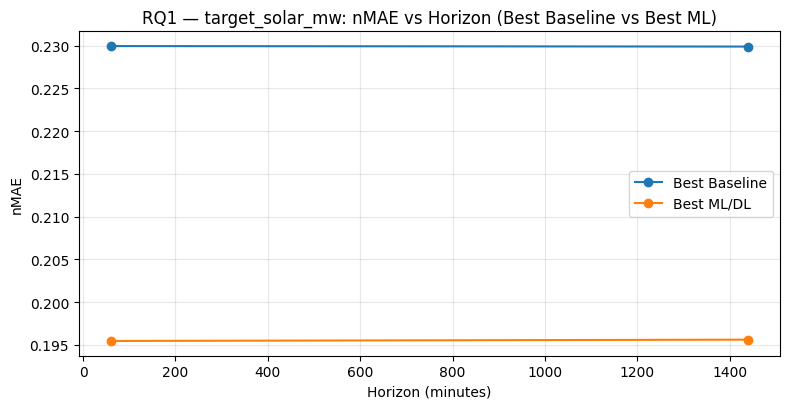

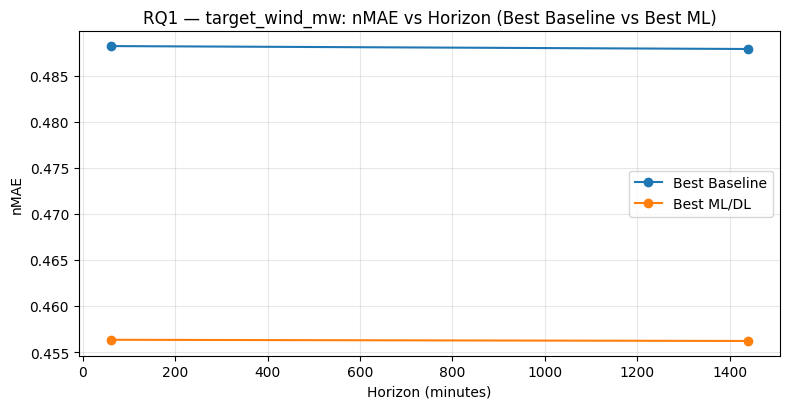


[Inference hints for RQ1]
  target_solar_mw: baseline monotone↑=False, ML monotone↑=True
  target_wind_mw: baseline monotone↑=False, ML monotone↑=False


In [ ]:
# ==== Cell B: RQ1 plot — horizon vs error (best baseline vs best ML) ====
best_base = _best_by_group(results_df, METRIC, _is_baseline)
best_ml   = _best_by_group(results_df, METRIC, _is_ml)

rq1 = (best_base.merge(best_ml, on=["target","horizon_min"], how="outer", suffixes=("_baseline","_ml"))
              .sort_values(["target","horizon_min"]))
display(rq1.head())

# Plot per target
targets = rq1["target"].dropna().unique().tolist()
figs_rq1 = []
for t in targets:
    d = rq1[rq1["target"] == t]
    if d.empty:
        continue
    fig = plt.figure(figsize=(8,4.2))
    plt.plot(d["horizon_min"], d[f"{METRIC}_baseline"], marker="o", label="Best Baseline")
    plt.plot(d["horizon_min"], d[f"{METRIC}_ml"], marker="o", label="Best ML/DL")
    plt.xlabel("Horizon (minutes)")
    plt.ylabel(METRIC)
    plt.title(f"RQ1 — {t}: {METRIC} vs Horizon (Best Baseline vs Best ML)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    figs_rq1.append(fig)
plt.show()

# Simple textual inference helpers (optional printout)
def _monotone_check(x, y):
    # returns True if non-decreasing across horizons
    order = np.argsort(x.values)
    y_sorted = y.values[order]
    return np.all(np.diff(y_sorted) >= -1e-9)

print("\n[Inference hints for RQ1]")
for t in targets:
    d = rq1[rq1["target"] == t]
    if d.empty:
        continue
    ok_base = _monotone_check(d["horizon_min"], d[f"{METRIC}_baseline"])
    ok_ml   = _monotone_check(d["horizon_min"], d[f"{METRIC}_ml"])
    print(f"  {t}: baseline monotone↑={ok_base}, ML monotone↑={ok_ml}")


,target,horizon_min,model_base,nMAE_base,model_ml,nMAE_ml,improvement_pct
0,target_solar_mw,60,baseline_persistence,0.229935,xgb,0.195468,14.989855
1,target_solar_mw,1440,baseline_persistence,0.229878,xgb,0.195622,14.901988
2,target_wind_mw,60,baseline_seasonal,0.488198,xgb,0.456332,6.527178
3,target_wind_mw,1440,baseline_seasonal,0.487881,xgb,0.456202,6.493164


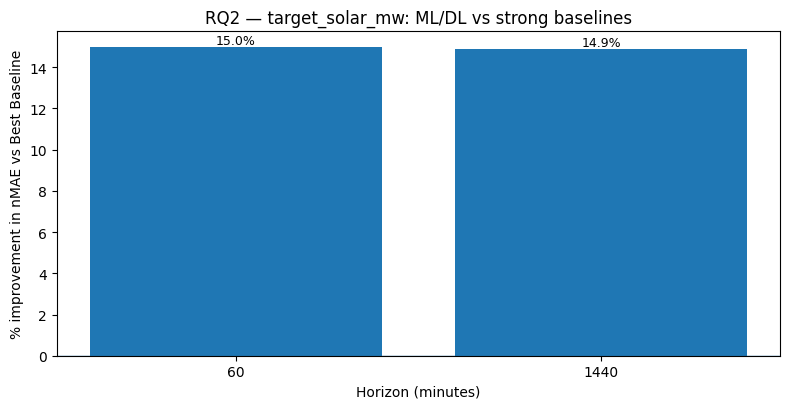

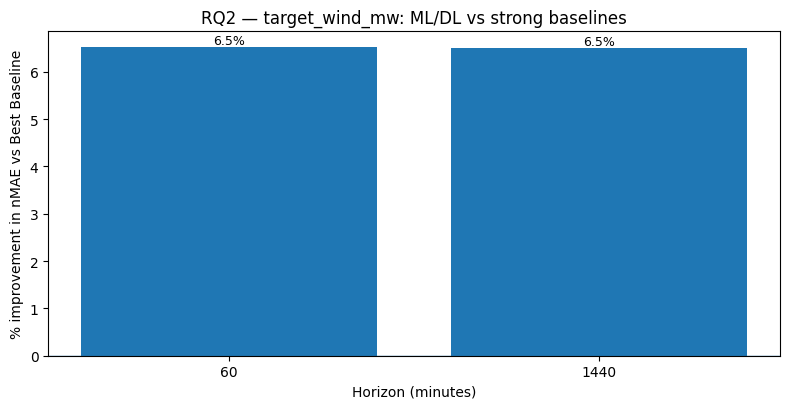

In [ ]:
# ==== Cell C: RQ2 bars — % improvement of best ML over best baseline per horizon ====
if not best_base.empty and not best_ml.empty:
    cmp = best_base.merge(best_ml, on=["target","horizon_min"], suffixes=("_base","_ml"))
    cmp["improvement_pct"] = 100.0 * (cmp[f"{METRIC}_base"] - cmp[f"{METRIC}_ml"]) / cmp[f"{METRIC}_base"]
    display(cmp.sort_values(["target","horizon_min"]))

    figs_rq2 = []
    for t in cmp["target"].unique():
        d = cmp[cmp["target"] == t].sort_values("horizon_min")
        fig = plt.figure(figsize=(8,4.2))
        plt.bar(d["horizon_min"].astype(str), d["improvement_pct"])
        for x, y in zip(d["horizon_min"].astype(str), d["improvement_pct"]):
            plt.text(x, y, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)
        plt.axhline(0, linewidth=1)
        plt.xlabel("Horizon (minutes)")
        plt.ylabel(f"% improvement in {METRIC} vs Best Baseline")
        plt.title(f"RQ2 — {t}: ML/DL vs strong baselines")
        plt.tight_layout()
        figs_rq2.append(fig)
    plt.show()
else:
    print("Not enough info to compute RQ2 (need identifiable baselines and ML models).")


,target,horizon_min,pooled_MAE,mean(spec-pooled),delta,TOST_p,non_inferior_at_1pct,spec_MAE,improvement_pct,decision
1,target_solar_mw,60,0.153304,-0.089913,0.001533,0.999074,False,0.063391,58.650181,not non-inferior (±1%)
0,target_wind_mw,60,0.908031,-0.002588,0.009080,0.260758,False,0.905443,0.284991,not non-inferior (±1%)


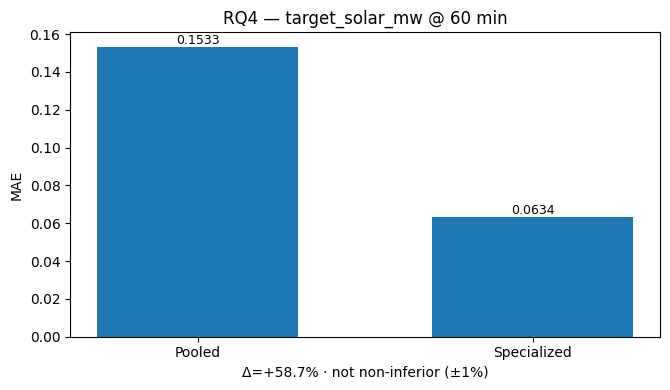

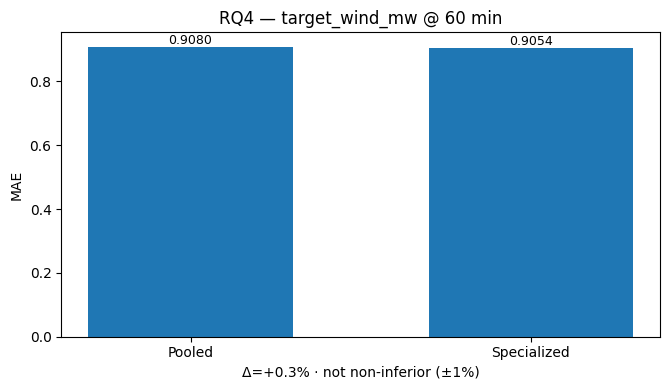

In [ ]:
# ==== Cell D: RQ4 plots — pooled vs specialized, with TOST flags (from rq4_df) ====
_required = ["target","horizon_min","pooled_MAE","mean(spec-pooled)","delta"]
_missing = [c for c in _required if c not in rq4_df.columns]
if _missing:
    raise ValueError(f"rq4_df is missing columns: {_missing}")

rq4v = rq4_df.copy()
rq4v["spec_MAE"] = rq4v["pooled_MAE"] + rq4v["mean(spec-pooled)"]
rq4v["improvement_pct"] = 100.0 * (rq4v["pooled_MAE"] - rq4v["spec_MAE"]) / rq4v["pooled_MAE"]
# Optional booleans if columns exist
if "TOST_p" in rq4v.columns and "non_inferior_at_1pct" in rq4v.columns:
    rq4v["decision"] = np.where(rq4v["non_inferior_at_1pct"], "non-inferior (±1%)", "not non-inferior (±1%)")
else:
    rq4v["decision"] = ""

display(rq4v.sort_values(["target","horizon_min"]))

# Side-by-side bars for each target/horizon
figs_rq4 = []
for (t, h), d in rq4v.groupby(["target","horizon_min"]):
    pooled = float(d["pooled_MAE"].iloc[0])
    spec   = float(d["spec_MAE"].iloc[0])
    imp    = float(d["improvement_pct"].iloc[0])
    dec    = str(d["decision"].iloc[0])

    fig = plt.figure(figsize=(6.8,4))
    xs = np.arange(2)
    vals = [pooled, spec]
    plt.bar(xs, vals, width=0.6)
    for x, y in zip(xs, vals):
        plt.text(x, y, f"{y:.4f}", ha="center", va="bottom", fontsize=9)
    plt.xticks(xs, ["Pooled", "Specialized"])
    subtitle = f"Δ={imp:+.1f}%"
    if dec:
        subtitle += f" · {dec}"
    plt.title(f"RQ4 — {t} @ {h} min", fontsize=12)
    plt.ylabel("MAE")
    plt.xlabel(subtitle)
    plt.tight_layout()
    figs_rq4.append(fig)
plt.show()


In [ ]:
# ==== Cell E: export figures + summaries (optional) ====
# Reuse the export_to_drive(...) function you already added.
# Add our summary frames so they get saved too.

summary_frames = {
    "rq1_best_base_vs_ml": rq1,
    "rq2_improvement": (cmp if 'cmp' in locals() else pd.DataFrame()),
    "rq4_view": rq4v
}

for name, df in summary_frames.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        globals()[name] = df  # ensure present in globals for exporter discovery

_ = export_to_drive(
    base_dir="/content/drive/MyDrive/Colab Notebooks/renewables_outputs/capstone",
    select=list(summary_frames.keys()),   # plus any others you want like "results_df", "rq4_df", "summary"
    save_figs=True,
    zip_run=True
)


[Export] Saved 14 artifacts to:
/content/drive/MyDrive/Colab Notebooks/renewables_outputs/capstone/run_20250912T150127Z
[Export] Zipped archive:
/content/drive/MyDrive/Colab Notebooks/renewables_outputs/capstone/run_20250912T150127Z.zip


In [ ]:
# ============================
# Feature listing + importance (for refined_df.csv)
# Drop this cell into Research_Question.ipynb and run.
# ============================

import os, glob, json
import numpy as np
import pandas as pd

# ------------------
# CONFIG
# ------------------
CSV_CANDIDATES = [
    "refined_df.csv",
    "/content/refined_df.csv",
    "/content/drive/MyDrive/Colab Notebooks/renewables_outputs/merged_by_continent/refined dataset/refined_df.csv",
]
TIMESTAMP_COLS = {"ts_utc","timestamp","time","datetime","date_time","ds"}
POSSIBLE_TARGETS = ["target_solar_mw","target_wind_mw"]  # add here if your targets differ
SAMPLE_FRAC = 0.15          # down-sample to speed up importance; increase if you want more precision
MAX_SAMPLE_ROWS = 1_000_000 # safety cap
CHUNKSIZE = 250_000         # streaming read to keep RAM in check
RANDOM_STATE = 42
TOP_N_PRINT = 100           # how many features to show in the cell output
OUTDIR = "feature_outputs"

# ------------------
# Locate CSV
# ------------------
csv_path = None
for p in CSV_CANDIDATES:
    if os.path.exists(p):
        csv_path = p
        break
if csv_path is None:
    # last resort: try to find it anywhere in current tree (can be slower)
    hits = glob.glob("**/refined_df.csv", recursive=True)
    if hits:
        csv_path = hits[0]

if csv_path is None:
    raise FileNotFoundError(
        "Could not find refined_df.csv. Place it in the notebook folder or in /content or /content/drive/MyDrive."
    )

print(f"✅ Using file: {csv_path}")

# ------------------
# Read header only to list ALL columns
# ------------------
header = pd.read_csv(csv_path, nrows=0)
all_cols = header.columns.tolist()

# Identify targets
targets = [c for c in POSSIBLE_TARGETS if c in all_cols]
if not targets:
    # fallback: auto-detect any column that starts with 'target_'
    targets = [c for c in all_cols if c.lower().startswith("target_")]
if not targets:
    raise ValueError("No target columns found. Add their names to POSSIBLE_TARGETS or ensure they start with 'target_'.")

# Identify feature columns (exclude time-like + targets)
time_like = {c for c in all_cols if c.lower() in TIMESTAMP_COLS}
non_feature_like = set()  # extend if you have ids / text columns you want to drop
feature_cols = [c for c in all_cols if c not in targets and c not in time_like and c not in non_feature_like]

# ------------------
# Print clean lists to output
# ------------------
print("\n=== ALL COLUMNS ({} total) ===".format(len(all_cols)))
for c in all_cols:
    print(c)

print("\n=== TARGET COLUMNS ({}): ===".format(len(targets)))
for c in targets:
    print(" -", c)

print("\n=== FEATURE COLUMNS ({}): ===".format(len(feature_cols)))
for c in feature_cols:
    print(" -", c)

# Save lists for your appendix
os.makedirs(OUTDIR, exist_ok=True)
with open(os.path.join(OUTDIR, "all_columns.txt"), "w", encoding="utf-8") as f:
    for c in all_cols: f.write(c + "\n")
with open(os.path.join(OUTDIR, "targets.txt"), "w", encoding="utf-8") as f:
    for c in targets: f.write(c + "\n")
with open(os.path.join(OUTDIR, "features.txt"), "w", encoding="utf-8") as f:
    for c in feature_cols: f.write(c + "\n")

# ------------------
# Load a sample for importance (numeric-only for the model)
# ------------------
usecols = feature_cols + targets
sample_parts = []
rows_accum = 0

for i, chunk in enumerate(pd.read_csv(csv_path, usecols=usecols, chunksize=CHUNKSIZE, low_memory=False)):
    # Drop rows with missing targets
    chunk = chunk.dropna(subset=targets)
    # Downsample per chunk for speed
    if SAMPLE_FRAC < 1.0:
        chunk = chunk.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE + i)
    sample_parts.append(chunk)
    rows_accum += len(chunk)
    if rows_accum >= MAX_SAMPLE_ROWS:
        break

if not sample_parts:
    raise RuntimeError("No data loaded for importance (after filtering). Check targets and file content.")

df = pd.concat(sample_parts, ignore_index=True)
print(f"\n📦 Loaded sample shape: {df.shape}")

# Keep numeric features only for model training
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()
numeric_features = X_all.columns.tolist()

dropped_non_num = set(feature_cols) - set(numeric_features)
if dropped_non_num:
    print(f"ℹ️ Dropped {len(dropped_non_num)} non-numeric features for importance (e.g., {list(dropped_non_num)[:5]})")

# ------------------
# Importance per target (XGBoost + optional SHAP)
# ------------------
def rank_importance_for_target(y_col, X, df):
    y = df[y_col].values

    # Prefer XGBoost if present; else fallback to RandomForest
    model_name = "xgboost"
    try:
        from xgboost import XGBRegressor
        model = XGBRegressor(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
    except Exception:
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        model_name = "random_forest"

    model.fit(X, y)

    # Base importance
    if model_name == "xgboost":
        booster = model.get_booster()
        gain = booster.get_score(importance_type="gain")
        imp_df = pd.DataFrame({"feature": list(gain.keys()), "gain_importance": list(gain.values())})
    else:
        imp = getattr(model, "feature_importances_", None)
        if imp is None:
            raise RuntimeError("The fallback model did not expose feature_importances_.")
        imp_df = pd.DataFrame({"feature": X.columns, "gain_importance": imp})

    imp_df = imp_df.sort_values("gain_importance", ascending=False)

    # Try SHAP for a stronger ranking (if installed)
    shap_df = None
    try:
        import shap
        try:
            explainer = shap.TreeExplainer(model)
            shap_X = X.sample(n=min(5000, len(X)), random_state=RANDOM_STATE)
            shap_values = explainer.shap_values(shap_X)
            mean_abs = np.mean(np.abs(shap_values), axis=0)
            shap_df = pd.DataFrame({"feature": shap_X.columns, "mean_abs_shap": mean_abs}).sort_values(
                "mean_abs_shap", ascending=False
            )
        except Exception as e:
            print(f"(SHAP available but not used — {e})")
    except Exception:
        print("(SHAP not installed; proceeding with model importance only)")

    # Combine rankings (normalize each and average)
    if shap_df is not None:
        merged = pd.merge(shap_df, imp_df, on="feature", how="outer").fillna(0.0)
        for col in ["mean_abs_shap","gain_importance"]:
            vmax = merged[col].max()
            if vmax > 0: merged[col] = merged[col] / vmax
        merged["combined_score"] = merged[["mean_abs_shap","gain_importance"]].mean(axis=1)
        ranked = merged.sort_values("combined_score", ascending=False)
    else:
        ranked = imp_df.rename(columns={"gain_importance":"combined_score"}).sort_values("combined_score", ascending=False)

    # Nicely formatted display
    display_cols = ["feature","combined_score"]
    print(f"\n🔎 Top features for {y_col} (higher = more important):")
    from IPython.display import display
    display(ranked[display_cols].head(TOP_N_PRINT))

    # Save to CSV
    out_csv = os.path.join(OUTDIR, f"feature_importance_{y_col}.csv")
    ranked.to_csv(out_csv, index=False)
    print(f"💾 Saved: {out_csv}")

    return ranked

rankings = {}
for tgt in targets:
    rankings[tgt] = rank_importance_for_target(tgt, X_all, df)

# Save a JSON manifest with top-N for convenience
manifest = {tgt: df_i[["feature","combined_score"]].head(TOP_N_PRINT).to_dict(orient="records")
            for tgt, df_i in rankings.items()}
with open(os.path.join(OUTDIR, "feature_importance_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("\n✅ Done. Artifacts written to 'feature_outputs/'")
print("   - all_columns.txt")
print("   - targets.txt")
print("   - features.txt")
for tgt in targets:
    print(f"   - feature_importance_{tgt}.csv")
print("   - feature_importance_manifest.json")


✅ Using file: /content/drive/MyDrive/Colab Notebooks/renewables_outputs/merged_by_continent/refined dataset/refined_df.csv

=== ALL COLUMNS (24 total) ===
site_id
lat
lon
met_ghi
met_dni
met_dhi
met_temp_c
met_pressure_hpa
met_cloud_cover
met_wind_speed_10m
met_wind_speed_100m
target_wind_mw
target_solar_mw
continent
ts_utc
ts_local
hour
doy
month
weekday
is_weekend
is_daylight
solar_struct_zero
wind_near_zero

=== TARGET COLUMNS (2): ===
 - target_solar_mw
 - target_wind_mw

=== FEATURE COLUMNS (21): ===
 - site_id
 - lat
 - lon
 - met_ghi
 - met_dni
 - met_dhi
 - met_temp_c
 - met_pressure_hpa
 - met_cloud_cover
 - met_wind_speed_10m
 - met_wind_speed_100m
 - continent
 - ts_local
 - hour
 - doy
 - month
 - weekday
 - is_weekend
 - is_daylight
 - solar_struct_zero
 - wind_near_zero

📦 Loaded sample shape: (404712, 23)
ℹ️ Dropped 7 non-numeric features for importance (e.g., ['site_id', 'is_weekend', 'continent', 'ts_local', 'wind_near_zero'])

🔎 Top features for target_solar_mw (highe

,feature,combined_score
7,met_ghi,1.000000
6,met_dni,0.147140
5,met_dhi,0.095766
9,met_temp_c,0.018733
4,met_cloud_cover,0.006534
1,hour,0.001526
2,lat,0.001384
3,lon,0.001357
0,doy,0.000226
8,met_pressure_hpa,0.000141


💾 Saved: feature_outputs/feature_importance_target_solar_mw.csv

🔎 Top features for target_wind_mw (higher = more important):


,feature,combined_score
10,met_wind_speed_100m,1.000000
11,met_wind_speed_10m,0.085342
5,met_dhi,0.037328
7,met_ghi,0.009868
6,met_dni,0.002393
3,lon,0.001444
9,met_temp_c,0.001348
2,lat,0.001246
8,met_pressure_hpa,0.001089
4,met_cloud_cover,0.001027


💾 Saved: feature_outputs/feature_importance_target_wind_mw.csv

✅ Done. Artifacts written to 'feature_outputs/'
   - all_columns.txt
   - targets.txt
   - features.txt
   - feature_importance_target_solar_mw.csv
   - feature_importance_target_wind_mw.csv
   - feature_importance_manifest.json


In [ ]:
!cp -r /content/feature_outputs "/content/drive/MyDrive/Colab Notebooks/renewables_outputs/merged_by_continent/refined dataset/"


In [ ]:
# ===== Reconciling "why 178 features?" — reproduce the post-encoding width =====
import os
import pandas as pd
import numpy as np

# --- CONFIG (tweak to match your earlier runs) ---
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/renewables_outputs/merged_by_continent/refined dataset/refined_df.csv"

time_cols = ["ts_utc","ts_local"]
target_cols = ["target_solar_mw","target_wind_mw"]

# numeric meteorology & spatial
base_numeric = [
    "lat","lon",
    "met_ghi","met_dni","met_dhi",
    "met_temp_c","met_pressure_hpa","met_cloud_cover",
    "met_wind_speed_10m","met_wind_speed_100m"
]

# categorical to one-hot
cat_cols = ["continent"]  # add "site_id" ONLY if you want many dummies (can explode col count!)

# time/seasonality already present as integers:
time_basic = ["hour","doy","month","weekday","is_weekend"]  # we will sin/cos encode hour,doy,month

# binary structural flags (keep as-is)
flags = ["is_daylight","solar_struct_zero","wind_near_zero"]

# which variables get lag/rolling features
lag_vars = [
    "met_ghi","met_dni","met_dhi",
    "met_temp_c","met_pressure_hpa","met_cloud_cover",
    "met_wind_speed_10m","met_wind_speed_100m",
    # include lagged targets if your earlier pipeline did (safe for ≥60-min horizons):
    # "target_solar_mw","target_wind_mw",
]
lag_steps = [1, 3, 6, 24]         # adjust to match earlier notebook
roll_windows = [6, 24]            # rolling mean/std windows
roll_stats = ["mean", "std"]

# --- LOAD ---
df = pd.read_csv(CSV_PATH, parse_dates=[c for c in time_cols if c in ["ts_utc","ts_local"]], low_memory=False)
df = df.sort_values("ts_utc" if "ts_utc" in df.columns else time_cols[0]).reset_index(drop=True)

# --- start from a clean base X ---
use_cols = [c for c in base_numeric + cat_cols + time_basic + flags + target_cols + time_cols if c in df.columns]
X = df[use_cols].copy()

report = {}

# 1) Seasonality encodings (sin/cos for hour, doy, month)
def sincos(col, period):
    return np.sin(2*np.pi*X[col]/period), np.cos(2*np.pi*X[col]/period)

season_cols = []
if "hour" in X:
    s, c = sincos("hour", 24); X["hour_sin"], X["hour_cos"] = s, c; season_cols += ["hour_sin","hour_cos"]
if "doy" in X:
    s, c = sincos("doy", 365.25); X["doy_sin"], X["doy_cos"] = s, c; season_cols += ["doy_sin","doy_cos"]
if "month" in X:
    s, c = sincos("month", 12); X["month_sin"], X["month_cos"] = s, c; season_cols += ["month_sin","month_cos"]

# Remove raw cyclical ints if you did so earlier (keeps model from “cheating” on ordinality)
drop_time_ints = ["hour","doy","month"]
keep_time_ints = [c for c in time_basic if c not in drop_time_ints]
X_seasonal = X.drop(columns=[c for c in drop_time_ints if c in X.columns], errors="ignore")

report["seasonality_added"] = len(season_cols)

# 2) One-hot encoding for categoricals
X_ohe = pd.get_dummies(X_seasonal, columns=[c for c in cat_cols if c in X_seasonal.columns], drop_first=True)
new_ohe_cols = [c for c in X_ohe.columns if any(cc + "_" in c for cc in cat_cols)]
report["one_hot_added"] = len(new_ohe_cols)

# 3) Lag features
X_lag = X_ohe.copy()
lag_added = 0
for v in lag_vars:
    if v not in X_lag.columns:
        continue
    for L in lag_steps:
        X_lag[f"{v}_lag{L}"] = X_lag[v].shift(L)
        lag_added += 1
report["lags_added"] = lag_added

# 4) Rolling mean/std features
X_roll = X_lag.copy()
roll_added = 0
for v in lag_vars:
    if v not in X_roll.columns:
        continue
    for w in roll_windows:
        if "mean" in roll_stats:
            X_roll[f"{v}_roll{w}m"] = X_roll[v].rolling(window=w, min_periods=w).mean()
            roll_added += 1
        if "std" in roll_stats:
            X_roll[f"{v}_roll{w}s"] = X_roll[v].rolling(window=w, min_periods=w).std()
            roll_added += 1
report["rolling_added"] = roll_added

# 5) Final cleanup: drop targets & any time stamps (keep binary flags if desired)
to_drop = [c for c in target_cols + time_cols if c in X_roll.columns]
X_final = X_roll.drop(columns=to_drop).dropna()

# Count groups for a clear breakdown
base_keep = [c for c in base_numeric + keep_time_ints + flags if c in X_final.columns]
season_keep = [c for c in season_cols if c in X_final.columns]
ohe_keep = [c for c in X_final.columns if any(cc + "_" in c for cc in cat_cols)]
lag_keep = [c for c in X_final.columns if any(c.endswith(f"_lag{L}") for L in lag_steps)]
roll_keep = [c for c in X_final.columns if any(f"_roll" in c for c in X_final.columns)]

print("=== FEATURE COUNT BREAKDOWN ===")
print(f"Base numeric + kept time ints + flags: {len(base_keep)}")
print(f"Seasonality (sin/cos):                {len(season_keep)}")
print(f"One-hot categoricals:                 {len(ohe_keep)}")
print(f"Lags added:                           {len(lag_keep)}")
print(f"Rolling stats added:                  {len(roll_keep)}")

print("\n=== FINAL ENCODED SHAPE ===")
print(f"X_final: {X_final.shape}  (rows, cols)")

# Optional: show a few example columns from each group
def sample(cols, k=8):
    cols = list(cols)
    return cols[:min(k, len(cols))]

print("\nExamples:")
print("  Base   :", sample(base_keep))
print("  Season :", sample(season_keep))
print("  OHE    :", sample(ohe_keep))
print("  Lags   :", sample(lag_keep))
print("  Rolling:", sample(roll_keep))


=== FEATURE COUNT BREAKDOWN ===
Base numeric + kept time ints + flags: 15
Seasonality (sin/cos):                6
One-hot categoricals:                 3
Lags added:                           32
Rolling stats added:                  88

=== FINAL ENCODED SHAPE ===
X_final: (2698056, 88)  (rows, cols)

Examples:
  Base   : ['lat', 'lon', 'met_ghi', 'met_dni', 'met_dhi', 'met_temp_c', 'met_pressure_hpa', 'met_cloud_cover']
  Season : ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  OHE    : ['continent_AS', 'continent_AU', 'continent_EU']
  Lags   : ['met_ghi_lag1', 'met_ghi_lag3', 'met_ghi_lag6', 'met_ghi_lag24', 'met_dni_lag1', 'met_dni_lag3', 'met_dni_lag6', 'met_dni_lag24']
  Rolling: ['lat', 'lon', 'met_ghi', 'met_dni', 'met_dhi', 'met_temp_c', 'met_pressure_hpa', 'met_cloud_cover']


# cell 1 — RQ1: accuracy vs horizon (line plot)

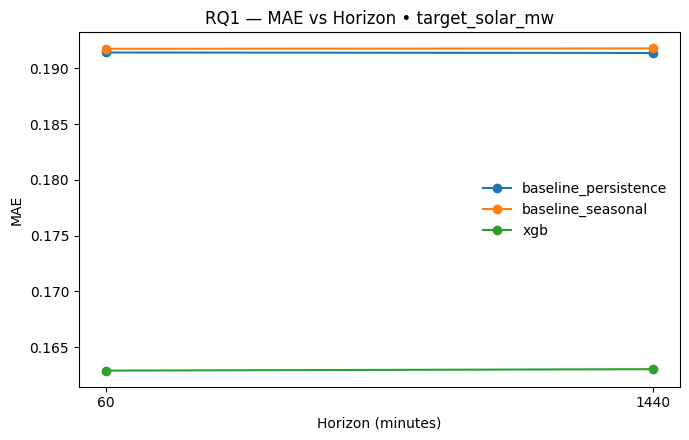

saved: figures/RQ1_mae_vs_horizon_target_solar_mw.png


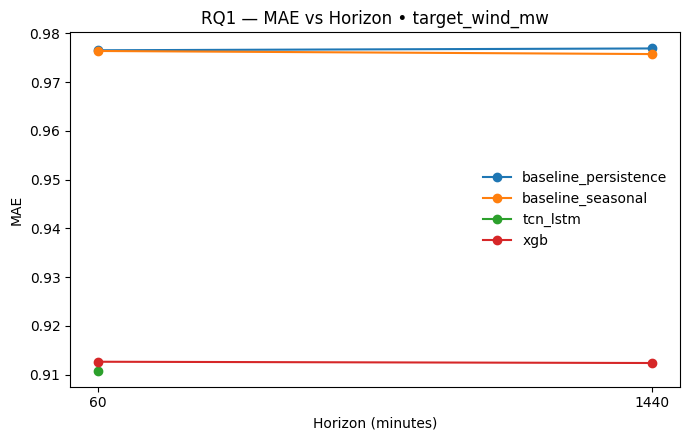

saved: figures/RQ1_mae_vs_horizon_target_wind_mw.png


In [ ]:
# --- RQ1: MAE by horizon (per target & model) ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# this expects your evaluation table from earlier runs.
# if your notebook already has `results_df`, we’ll use it.
# otherwise, adjust the CSV path to wherever you saved results.
try:
    _ = results_df
except NameError:
    # fallback: look for an exported results file (adjust if needed)
    CANDIDATES = [
        "results_df.csv",
        "/content/drive/MyDrive/results_df.csv",
        "/content/results_df.csv",
    ]
    path = next((p for p in CANDIDATES if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError("Could not find results_df (in-memory or CSV). Export it earlier in the notebook.")
    results_df = pd.read_csv(path)

# keep only the essentials
need = ["target","horizon_min","model","MAE","RMSE"]
have = [c for c in need if c in results_df.columns]
df = results_df[have].copy()

# choose 60 and 1440 (1-hour & day-ahead); include others if present
keep_hz = [60, 1440]
df = df[df["horizon_min"].isin(keep_hz)]

# plot: one line per model, x=horizon, y=MAE (separate plots per target)
for tgt in sorted(df["target"].unique()):
    sub = df[df["target"] == tgt]
    pivot = sub.pivot_table(index="horizon_min", columns="model", values="MAE", aggfunc="mean").sort_index()
    plt.figure(figsize=(7,4.5))
    for m in pivot.columns:
        plt.plot(pivot.index, pivot[m], marker="o", label=m)
    plt.title(f"RQ1 — MAE vs Horizon • {tgt}")
    plt.xlabel("Horizon (minutes)")
    plt.ylabel("MAE")
    plt.xticks(pivot.index)
    plt.legend(frameon=False)
    plt.tight_layout()
    out = f"figures/RQ1_mae_vs_horizon_{tgt}.png"
    plt.savefig(out, dpi=200)
    plt.show()
    print("saved:", out)
